# Evaluation: Порівняння підходів до генерації звітів

Три методи: **baseline_rag**, **mmr_rag**, **raw_generation**  
Дані завантажуються прямо з CSV-файлів експериментів.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
from pathlib import Path
from scipy import stats
from itertools import combinations

# ── Violet / purple palette ───────────────────────────────────────────────────
PURPLE = {
    "deep":     "#5B3DC8",   # deep indigo-violet
    "mid":      "#9575CD",   # medium violet
    "light":    "#C9B8F0",   # light lavender
    "positive": "#7C3AED",   # vivid violet  (δ better)
    "negative": "#C06B8E",   # muted rose     (δ worse)
    "grid":     "#EDE9FE",   # very light lavender for backgrounds
}

METHOD_COLORS = {
    "baseline_rag":   PURPLE["deep"],
    "mmr_rag":        PURPLE["mid"],
    "raw_generation": PURPLE["light"],
}
LANG_COLORS = {
    "Ukrainian": PURPLE["deep"],
    "English":   "#B39DDB",  # soft lavender — distinct but same family
}

sns.set_theme(
    style="whitegrid",
    font_scale=1.05,
    rc={
        "axes.facecolor":    "#FAFAFE",
        "figure.facecolor":  "#FFFFFF",
        "grid.color":        "#E9E4F8",
        "axes.edgecolor":    "#C4B9EB",
        "axes.spines.top":   False,
        "axes.spines.right": False,
    },
)

EXPERIMENTS = Path("../../experiments")

METRIC_COLS = [
    "faithfulness_report",
    "answer_relevancy_report",
    "diversity",
    "temporal_coverage",
    "context_precision",
]
TECH_COLS = ["report_tokens_used", "report_generation_time"]

METRIC_LABELS = {
    "faithfulness_report":     "Достовірність",
    "answer_relevancy_report": "Релевантність відповіді",
    "diversity":               "Різноманітність",
    "temporal_coverage":       "Часове покриття",
    "context_precision":       "Точність контексту",
}
TECH_LABELS = {
    "report_tokens_used":     "Токени (звіт)",
    "report_generation_time": "Час генерації (сек)",
}
PERIOD_LABELS = {"week": "Тиждень", "month": "Місяць", "year": "Рік"}
PERIOD_ORDER  = ["week", "month", "year"]

In [48]:
dfs = []
for fname in ["results_baseline_rag.csv", "results_mmr_rag.csv", "results_raw_generation_full.csv"]:
    tmp = pd.read_csv(EXPERIMENTS / fname)
    tmp = tmp.rename(columns={"user_id": "userId"})
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

KEEP = ["method", "period_type", "period_start", "userId"] + METRIC_COLS + TECH_COLS + ["temporal_breadth"]
df = df[[c for c in KEEP if c in df.columns]].copy()

for col in METRIC_COLS + TECH_COLS + ["temporal_breadth"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

METHODS = sorted(df["method"].unique())

print(f"Всього рядків: {len(df)}")
print()
print(df.groupby(["method", "period_type"]).size().rename("count").to_string())

Всього рядків: 1051

method          period_type
baseline_rag    month           63
                week           275
                year            10
mmr_rag         month           65
                week           274
                year            10
raw_generation  month           65
                week           279
                year            10


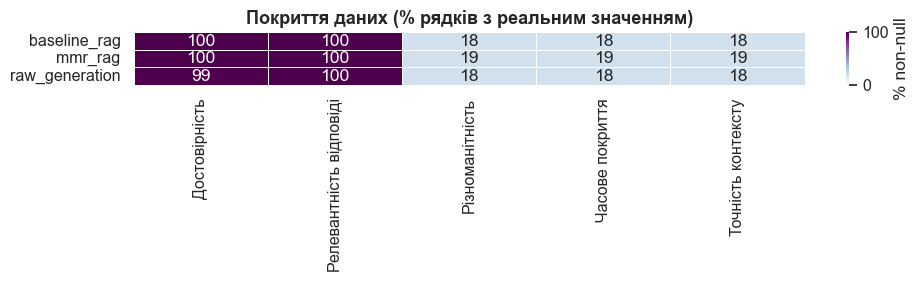


Примітка: diversity / temporal_coverage / context_precision — тільки для місяців та року.


In [49]:
# Покриття даних — які метрики скільки мають
cov = df.groupby("method")[METRIC_COLS].apply(lambda g: g.notna().mean() * 100)
cov.columns = [METRIC_LABELS[c] for c in METRIC_COLS]

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    cov, annot=True, fmt=".0f", cmap="BuPu",
    vmin=0, vmax=100, linewidths=0.6, linecolor="white",
    cbar_kws={"label": "% non-null"}, ax=ax
)
ax.set_title("Покриття даних (% рядків з реальним значенням)", fontsize=13, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("\nПримітка: diversity / temporal_coverage / context_precision — тільки для місяців та року.")

---
## 1. Основні метрики якості по методах

C:\Users\alina\AppData\Local\Temp\ipykernel_3616\615452262.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_3616\615452262.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


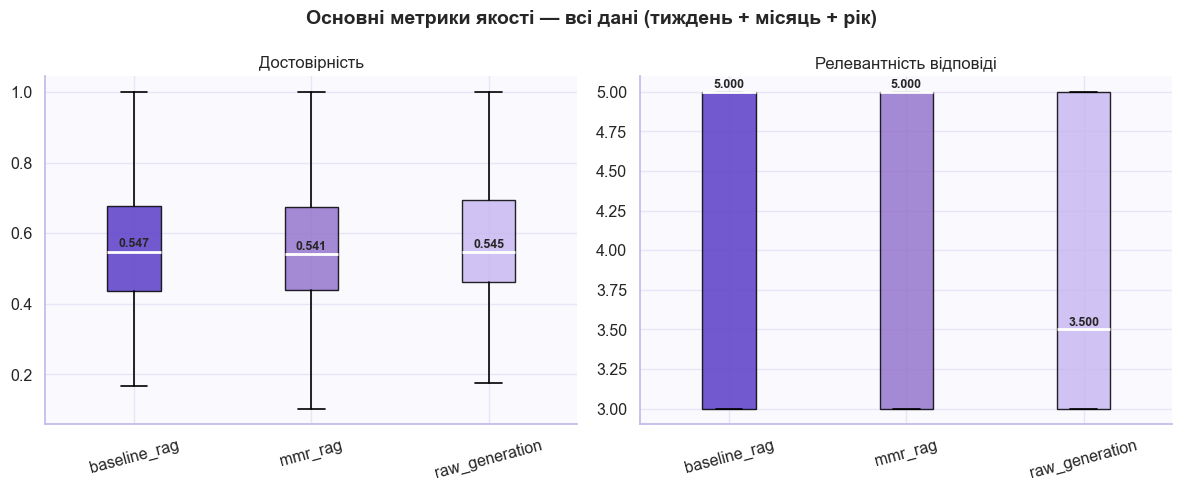

In [50]:
# faithfulness + answer_relevancy мають повне покриття — порівнюємо по всіх рядках
FULL_METRICS = ["faithfulness_report", "answer_relevancy_report"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Основні метрики якості — всі дані (тиждень + місяць + рік)",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, FULL_METRICS):
    data_by_method = [df[df["method"] == m][metric].dropna().values for m in METHODS]
    colors = [METHOD_COLORS[m] for m in METHODS]

    bp = ax.boxplot(
        data_by_method,
        labels=METHODS,
        patch_artist=True,
        medianprops={"color": "white", "linewidth": 2},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    # Підписи медіан
    for i, vals in enumerate(data_by_method):
        if len(vals):
            med = np.median(vals)
            ax.text(i + 1, med + 0.005, f"{med:.3f}",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

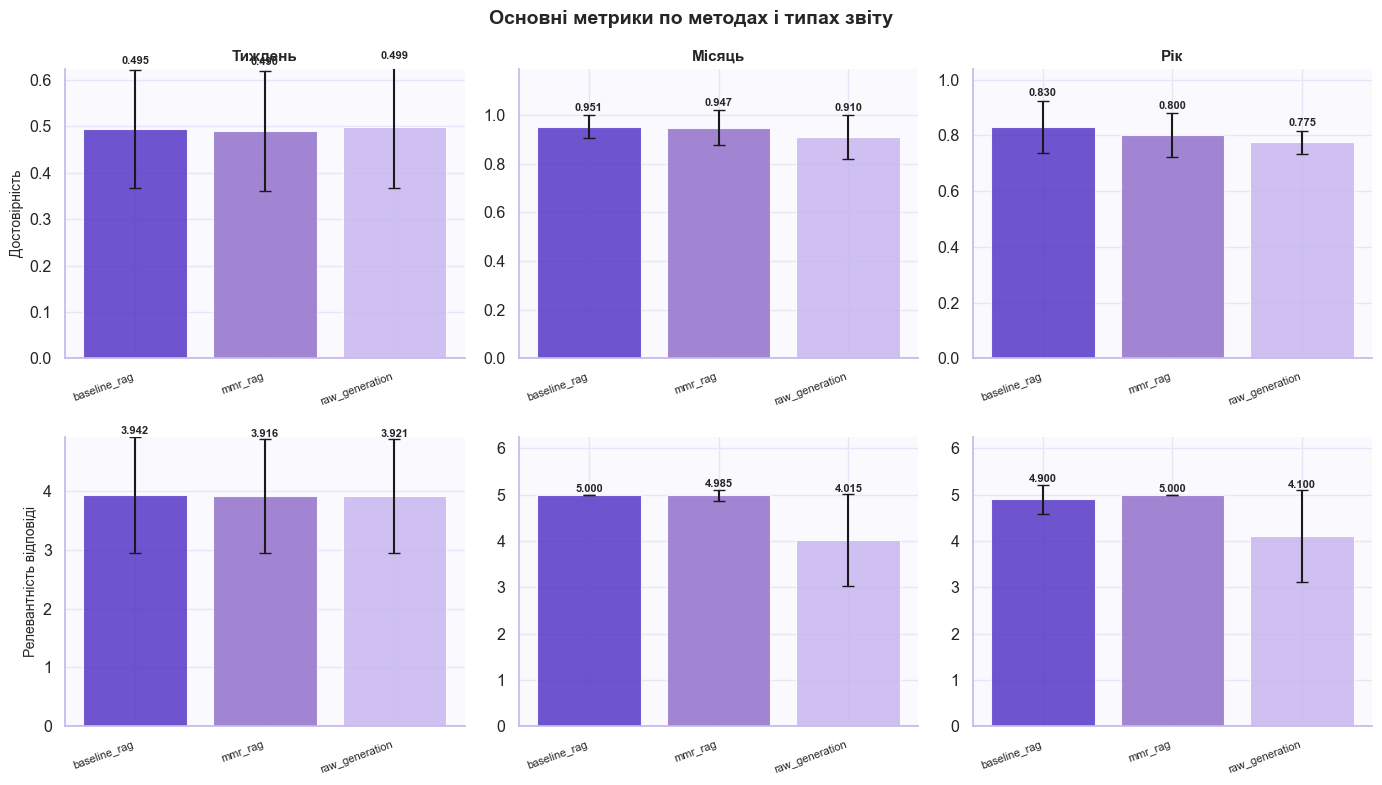

In [51]:
# Ті ж метрики, але розбиті по типу period
fig, axes = plt.subplots(2, len(PERIOD_ORDER), figsize=(14, 8), sharey=False)
fig.suptitle("Основні метрики по методах і типах звіту", fontsize=14, fontweight="bold")

for row, metric in enumerate(FULL_METRICS):
    for col, period in enumerate(PERIOD_ORDER):
        ax = axes[row][col]
        sub = df[df["period_type"] == period]
        means = sub.groupby("method")[metric].mean().reindex(METHODS)
        stds  = sub.groupby("method")[metric].std().reindex(METHODS)

        colors = [METHOD_COLORS[m] for m in METHODS]
        bars = ax.bar(
            range(len(METHODS)), means.values,
            yerr=stds.values, capsize=4,
            color=colors, edgecolor="white", linewidth=0.8, alpha=0.88
        )
        for bar, val in zip(bars, means.values):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (stds.values[list(means.values).index(val)] or 0) + 0.01,
                    f"{val:.3f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold"
                )

        if row == 0:
            ax.set_title(PERIOD_LABELS[period], fontsize=11, fontweight="bold")
        if col == 0:
            ax.set_ylabel(METRIC_LABELS[metric], fontsize=10)
        ax.set_xticks(range(len(METHODS)))
        ax.set_xticklabels(METHODS, rotation=20, ha="right", fontsize=8)
        valid = [v for v in means.values if not np.isnan(v)]
        if valid:
            ax.set_ylim(0, max(valid) * 1.25)

plt.tight_layout()
plt.show()

---
## 2. RAG-специфічні метрики (місяць + рік)

Метрики `diversity`, `temporal_coverage`, `context_precision` вимірювались лише для місячних і річних звітів.

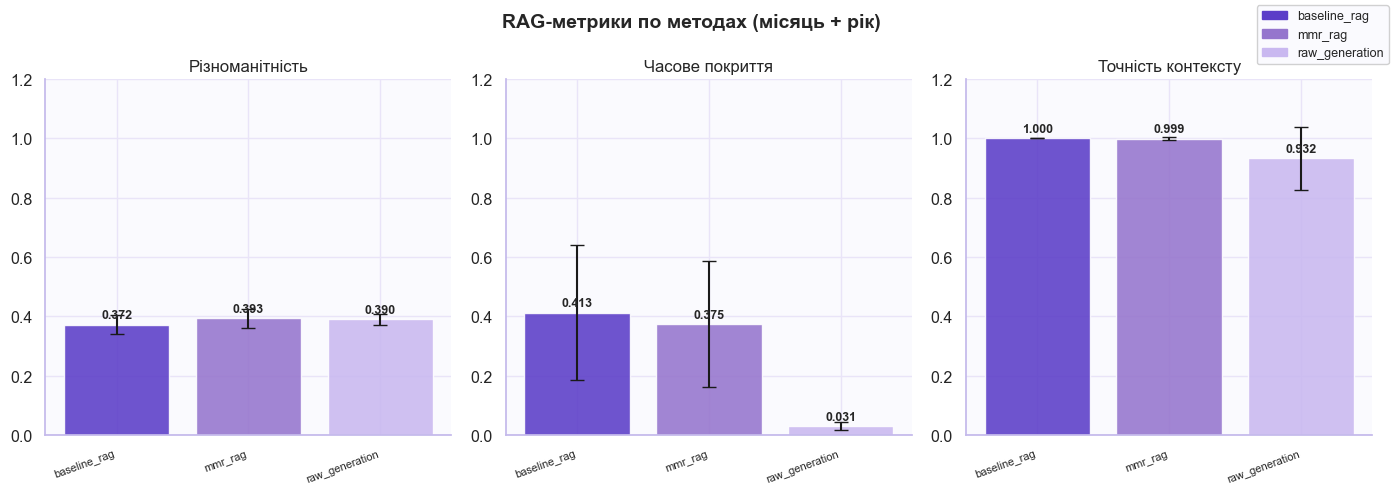

In [52]:
RAG_METRICS = ["diversity", "temporal_coverage", "context_precision"]
df_rag = df[df["period_type"].isin(["month", "year"])].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("RAG-метрики по методах (місяць + рік)", fontsize=14, fontweight="bold")

for ax, metric in zip(axes, RAG_METRICS):
    data_by_method = [df_rag[df_rag["method"] == m][metric].dropna().values for m in METHODS]
    means = [np.mean(v) if len(v) else np.nan for v in data_by_method]
    stds  = [np.std(v)  if len(v) else 0       for v in data_by_method]
    colors = [METHOD_COLORS[m] for m in METHODS]

    bars = ax.bar(
        range(len(METHODS)), means,
        yerr=stds, capsize=5,
        color=colors, edgecolor="white", alpha=0.88
    )
    for bar, val in zip(bars, means):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold"
            )

    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, rotation=20, ha="right", fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel("")

legend_patches = [mpatches.Patch(color=METHOD_COLORS[m], label=m) for m in METHODS]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

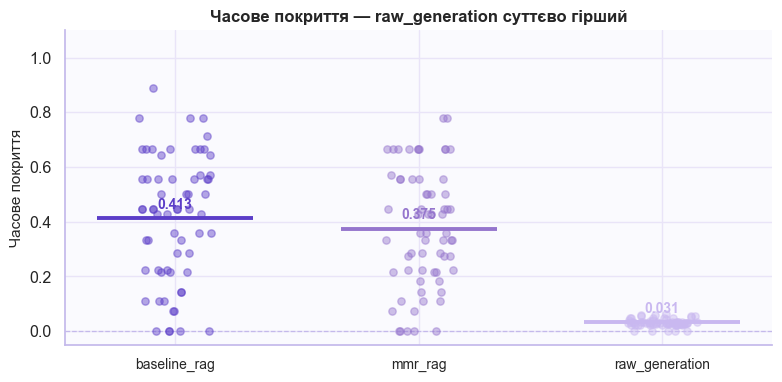

In [53]:
# Детальніше: temporal_coverage — найбільша різниця між методами
fig, ax = plt.subplots(figsize=(8, 4))

for i, method in enumerate(METHODS):
    vals  = df_rag[df_rag["method"] == method]["temporal_coverage"].dropna().values
    color = METHOD_COLORS[method]
    if len(vals):
        ax.scatter(
            np.full_like(vals, i, dtype=float) + np.random.uniform(-0.15, 0.15, len(vals)),
            vals,
            color=color, alpha=0.45, s=28, zorder=3
        )
        mean_val = np.mean(vals)
        ax.hlines(mean_val, i - 0.32, i + 0.32, color=color, linewidth=2.8, zorder=4)
        ax.text(i, mean_val + 0.035, f"{mean_val:.3f}",
                ha="center", fontsize=10, fontweight="bold", color=color)

ax.set_xticks(range(len(METHODS)))
ax.set_xticklabels(METHODS, fontsize=10)
ax.set_ylabel("Часове покриття", fontsize=11)
ax.set_ylim(-0.05, 1.1)
ax.set_title("Часове покриття — raw_generation суттєво гірший",
             fontsize=12, fontweight="bold")
ax.axhline(0, color="#C4B9EB", linewidth=0.9, linestyle="--")
plt.tight_layout()
plt.show()

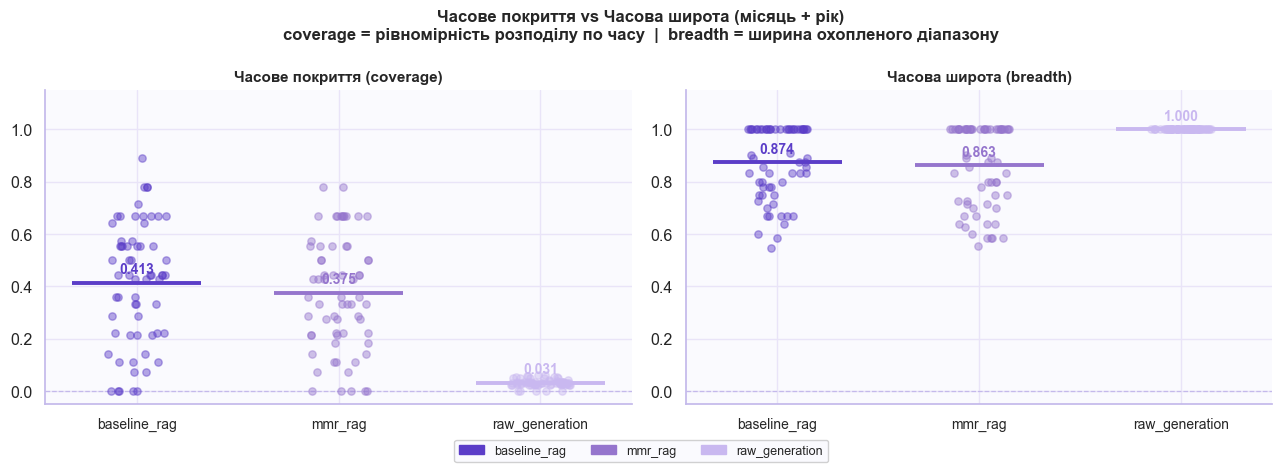


Середні значення по методах (місяць + рік):
                coverage (рівномірність)  breadth (ширина діапазону)
method                                                              
baseline_rag                      0.4132                      0.8737
mmr_rag                           0.3749                      0.8626
raw_generation                    0.0313                      1.0000


In [54]:
# temporal_breadth — наскільки широкий часовий діапазон охоплює звіт
# raw_generation = 1.0 завжди (доступ до всіх даних), RAG обмежений retrieved chunks
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    "Часове покриття vs Часова широта (місяць + рік)\n"
    "coverage = рівномірність розподілу по часу  |  breadth = ширина охопленого діапазону",
    fontsize=12, fontweight="bold"
)

for ax, (metric, title) in zip(axes, [
    ("temporal_coverage", "Часове покриття (coverage)"),
    ("temporal_breadth",  "Часова широта (breadth)"),
]):
    for i, method in enumerate(METHODS):
        vals  = df_rag[df_rag["method"] == method][metric].dropna().values
        color = METHOD_COLORS[method]
        if len(vals):
            jitter = np.random.uniform(-0.15, 0.15, len(vals))
            ax.scatter(
                np.full_like(vals, i, dtype=float) + jitter,
                vals, color=color, alpha=0.45, s=28, zorder=3
            )
            mean_val = np.mean(vals)
            ax.hlines(mean_val, i - 0.32, i + 0.32, color=color, linewidth=2.8, zorder=4)
            ax.text(i, mean_val + 0.035, f"{mean_val:.3f}",
                    ha="center", fontsize=10, fontweight="bold", color=color)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_ylim(-0.05, 1.15)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axhline(0, color="#C4B9EB", linewidth=0.9, linestyle="--")

legend_patches = [mpatches.Patch(color=METHOD_COLORS[m], label=m) for m in METHODS]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

# Зведена таблиця обох метрик
print("\nСередні значення по методах (місяць + рік):")
print(df_rag.groupby("method")[["temporal_coverage", "temporal_breadth"]]
      .mean().round(4).rename(columns={
          "temporal_coverage": "coverage (рівномірність)",
          "temporal_breadth":  "breadth (ширина діапазону)",
      }).to_string())

---
## 3. Δ відносно raw_generation — де RAG дає покращення

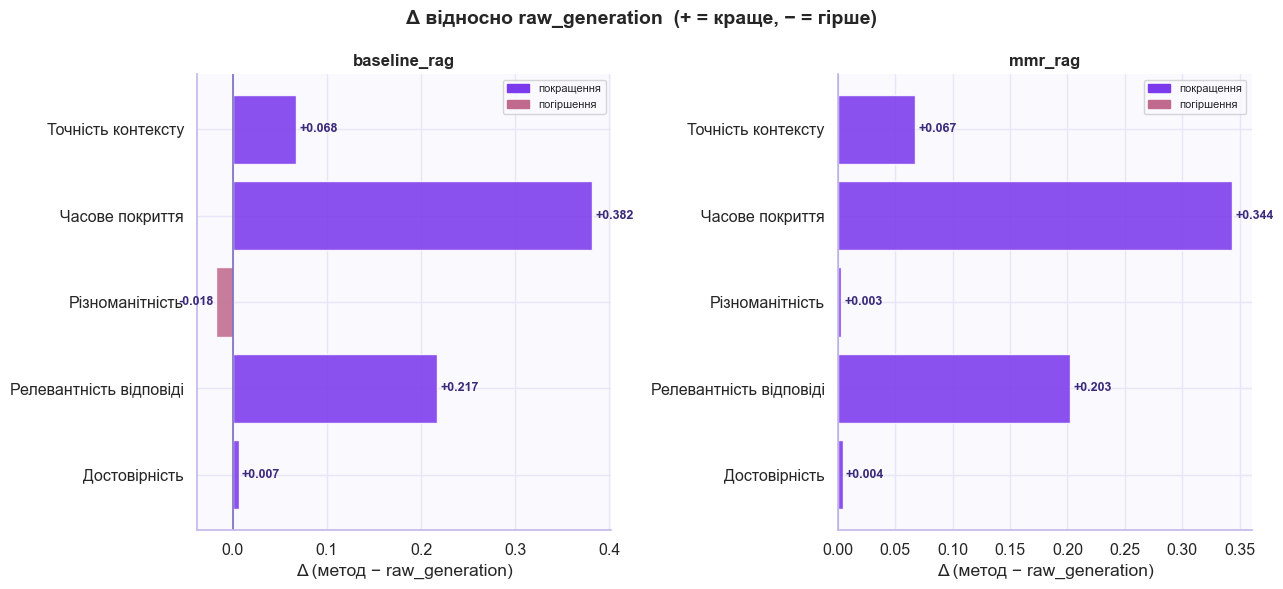

In [55]:
BASELINE = "raw_generation"
compare_methods = [m for m in METHODS if m != BASELINE]

ALL_METRICS = FULL_METRICS + RAG_METRICS
df_month_year = df[df["period_type"].isin(["month", "year"])]
df_all = df

fig, axes = plt.subplots(1, len(compare_methods), figsize=(13, 6))
if len(compare_methods) == 1:
    axes = [axes]
fig.suptitle(f"Δ відносно {BASELINE}  (+ = краще, − = гірше)",
             fontsize=14, fontweight="bold")

for ax, method in zip(axes, compare_methods):
    deltas = []
    labels = []
    for metric in ALL_METRICS:
        subset   = df_month_year if metric in RAG_METRICS else df_all
        base_val = subset[subset["method"] == BASELINE][metric].mean()
        meth_val = subset[subset["method"] == method][metric].mean()
        if pd.isna(base_val) or pd.isna(meth_val):
            continue
        deltas.append(meth_val - base_val)
        labels.append(METRIC_LABELS[metric])

    colors = [PURPLE["positive"] if d >= 0 else PURPLE["negative"] for d in deltas]
    bars   = ax.barh(labels, deltas, color=colors, edgecolor="white", alpha=0.88)
    ax.axvline(0, color="#7C6BC4", linewidth=1.2)

    for bar, val in zip(bars, deltas):
        x_pos = val + (0.003 if val >= 0 else -0.003)
        ha    = "left" if val >= 0 else "right"
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f"{val:+.3f}", va="center", ha=ha,
                fontsize=9, fontweight="bold", color="#3B2A7A")

    ax.set_title(f"{method}", fontsize=12, fontweight="bold")
    ax.set_xlabel(f"Δ (метод − {BASELINE})")

    good = mpatches.Patch(color=PURPLE["positive"], label="покращення")
    bad  = mpatches.Patch(color=PURPLE["negative"], label="погіршення")
    ax.legend(handles=[good, bad], fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Технічні метрики: токени та час генерації

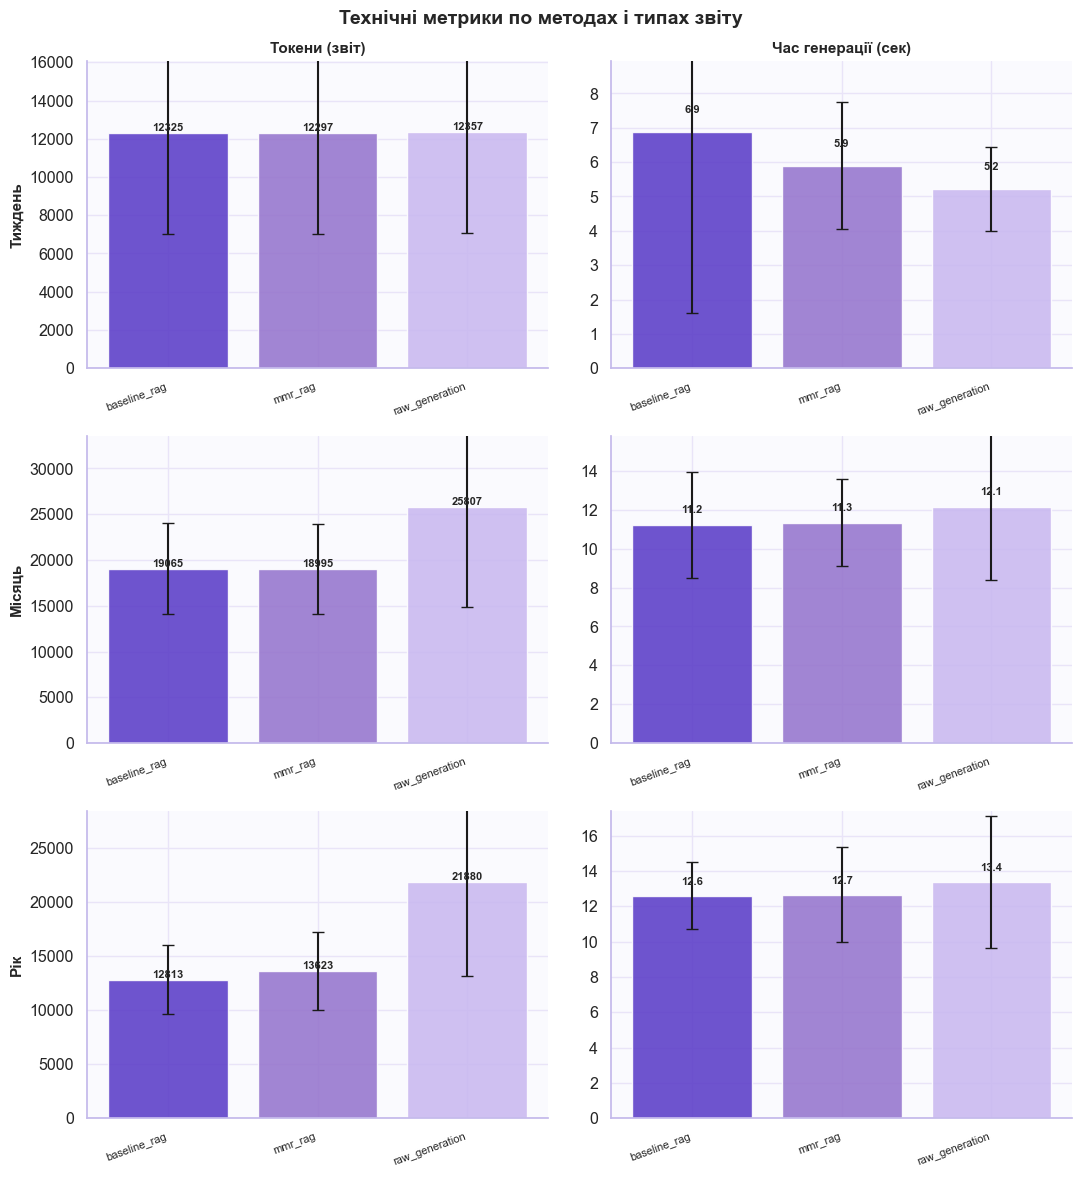

In [56]:
fig, axes = plt.subplots(
    len(PERIOD_ORDER), len(TECH_COLS),
    figsize=(11, 4 * len(PERIOD_ORDER)),
    squeeze=False
)
fig.suptitle("Технічні метрики по методах і типах звіту", fontsize=14, fontweight="bold")

for r_idx, period in enumerate(PERIOD_ORDER):
    sub   = df[df["period_type"] == period]
    means = sub.groupby("method")[TECH_COLS].mean()
    stds  = sub.groupby("method")[TECH_COLS].std()

    for c_idx, col in enumerate(TECH_COLS):
        ax     = axes[r_idx][c_idx]
        values = [means.loc[m, col] if m in means.index else np.nan for m in METHODS]
        errs   = [stds.loc[m, col]  if m in stds.index  else 0       for m in METHODS]
        colors = [METHOD_COLORS[m] for m in METHODS]

        bars = ax.bar(
            range(len(METHODS)), values,
            yerr=errs, capsize=4,
            color=colors, edgecolor="white", alpha=0.88
        )
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{val:.0f}" if col == "report_tokens_used" else f"{val:.1f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold"
                )

        if r_idx == 0:
            ax.set_title(TECH_LABELS[col], fontsize=11, fontweight="bold")
        if c_idx == 0:
            ax.set_ylabel(PERIOD_LABELS.get(period, period), fontsize=11, fontweight="bold")
        ax.set_xticks(range(len(METHODS)))
        ax.set_xticklabels(METHODS, rotation=20, ha="right", fontsize=8)
        valid = [v for v in values if not np.isnan(v)]
        if valid:
            ax.set_ylim(0, max(valid) * 1.30)

plt.tight_layout()
plt.show()

---
## 5. Статистична значущість (Mann-Whitney U)

`p < 0.05` — різниця статистично значуща; `p ≥ 0.05` — може бути випадковим шумом.

In [57]:
def run_mwu(subset, metrics, methods):
    rows = []
    for m1, m2 in combinations(methods, 2):
        for metric in metrics:
            a = subset[subset["method"] == m1][metric].dropna().values
            b = subset[subset["method"] == m2][metric].dropna().values
            if len(a) < 3 or len(b) < 3:
                rows.append({
                    "Пара": f"{m1} vs {m2}",
                    "Метрика": METRIC_LABELS.get(metric, metric),
                    "n1": len(a), "n2": len(b),
                    "mean1": round(a.mean(), 4) if len(a) else None,
                    "mean2": round(b.mean(), 4) if len(b) else None,
                    "p-value": None,
                    "Значущо?": "⚠️ замало даних",
                })
                continue
            _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            rows.append({
                "Пара": f"{m1} vs {m2}",
                "Метрика": METRIC_LABELS.get(metric, metric),
                "n1": len(a), "n2": len(b),
                "mean1": round(a.mean(), 4),
                "mean2": round(b.mean(), 4),
                "p-value": round(p, 4),
                "Значущо?": "✅ так" if p < 0.05 else "❌ ні",
            })
    return pd.DataFrame(rows).set_index(["Пара", "Метрика"])

# Спільні метрики — всі дані
print("=== Спільні метрики (faithfulness + relevancy) — всі period ===")
display(run_mwu(df, FULL_METRICS, METHODS))

# RAG-метрики — тільки місяць + рік
print("\n=== RAG-метрики (місяць + рік) ===")
display(run_mwu(df_month_year, RAG_METRICS, METHODS))

=== Спільні метрики (faithfulness + relevancy) — всі period ===


n1   n2   mean1  \
Пара                           Метрика                                     
baseline_rag vs mmr_rag        Достовірність            348  349  0.5868   
                               Релевантність відповіді  348  349  4.1609   
baseline_rag vs raw_generation Достовірність            348  351  0.5868   
                               Релевантність відповіді  348  354  4.1609   
mmr_rag vs raw_generation      Достовірність            349  351  0.5841   
                               Релевантність відповіді  349  354  4.1461   

                                                         mean2  p-value  \
Пара                           Метрика                                    
baseline_rag vs mmr_rag        Достовірність            0.5841   0.9607   
                               Релевантність відповіді  4.1461   0.7962   
baseline_rag vs raw_generation Достовірність            0.5802   0.9488   
                               Релевантність відповіді  3.9435   0.0030   
mmr_rag vs raw_generation      Достовірність            0.5802   0.8257   
                               Релевантність відповіді  3.9435   0.0057   

                                                       Значущо?  
Пара                           Метрика                           
baseline_rag vs mmr_rag        Достовірність               ❌ ні  
                               Релевантність відповіді     ❌ ні  
baseline_rag vs raw_generation Достовірність               ❌ ні  
                               Релевантність відповіді    ✅ так  
mmr_rag vs raw_generation      Достовірність               ❌ ні  
                               Релевантність відповіді    ✅ так


=== RAG-метрики (місяць + рік) ===


n1  n2   mean1   mean2  \
Пара                           Метрика                                      
baseline_rag vs mmr_rag        Різноманітність     63  65  0.3724  0.3930   
                               Часове покриття     63  65  0.4132  0.3749   
                               Точність контексту  63  65  1.0000  0.9992   
baseline_rag vs raw_generation Різноманітність     63  65  0.3724  0.3903   
                               Часове покриття     63  65  0.4132  0.0313   
                               Точність контексту  63  65  1.0000  0.9325   
mmr_rag vs raw_generation      Різноманітність     65  65  0.3930  0.3903   
                               Часове покриття     65  65  0.3749  0.0313   
                               Точність контексту  65  65  0.9992  0.9325   

                                                   p-value Значущо?  
Пара                           Метрика                               
baseline_rag vs mmr_rag        Різноманітність      0.0000    ✅ так  
                               Часове покриття      0.3086     ❌ ні  
                               Точність контексту   0.3326     ❌ ні  
baseline_rag vs raw_generation Різноманітність      0.0000    ✅ так  
                               Часове покриття      0.0000    ✅ так  
                               Точність контексту   0.0000    ✅ так  
mmr_rag vs raw_generation      Різноманітність      0.1653     ❌ ні  
                               Часове покриття      0.0000    ✅ так  
                               Точність контексту   0.0000    ✅ так

---
## 6. Зведена таблиця середніх значень

In [58]:
summary = df.groupby("method")[FULL_METRICS + TECH_COLS].mean().round(4)
summary.columns = [
    METRIC_LABELS.get(c, TECH_LABELS.get(c, c))
    for c in FULL_METRICS + TECH_COLS
]

rag_summary = df_month_year.groupby("method")[RAG_METRICS].mean().round(4)
rag_summary.columns = [METRIC_LABELS[c] for c in RAG_METRICS]

full_summary = summary.join(rag_summary)
display(
    full_summary.style
    .background_gradient(cmap="BuPu", axis=0)
    .format("{:.4f}")
    .set_caption("Середні значення метрик по методах (RAG-метрики: тільки місяць+рік)")
)

,Достовірність,Релевантність відповіді,Токени (звіт),Час генерації (сек),Різноманітність,Часове покриття,Точність контексту
method,,,,,,,
baseline_rag,0.5868,4.1609,13559.4856,7.8302,0.3724,0.4132,1.0000
mmr_rag,0.5841,4.1461,13582.3610,7.1005,0.3930,0.3749,0.9992
raw_generation,0.5802,3.9435,15095.8475,6.7225,0.3903,0.0313,0.9325


---
## 7. MMR RAG: порівняння за мовою звіту (Ukrainian vs English)

Мова визначається автоматично по кількості кириличних символів у тексті звіту.  
**Ukrainian**: user_id 21, 23, 25 — **English**: user_id 22, 24.

In [59]:
# Завантажуємо MMR окремо (з generated_text для детекції мови)
mmr_raw = pd.read_csv(EXPERIMENTS / "results_mmr_rag.csv", encoding="utf-8")

def detect_lang(text):
    if pd.isna(text):
        return "unknown"
    cyrillic = len(re.findall(r"[а-яіїєёА-ЯІЇЄЁ]", str(text)[:500]))
    return "Ukrainian" if cyrillic > 5 else "English"

mmr_raw["language"] = mmr_raw["generated_text"].apply(detect_lang)
mmr_raw = mmr_raw.rename(columns={"user_id": "userId"})

for col in METRIC_COLS + TECH_COLS:
    mmr_raw[col] = pd.to_numeric(mmr_raw[col], errors="coerce")

lang_counts = mmr_raw.groupby(["language", "period_type"]).size().rename("n")
print("Розподіл за мовою та типом звіту:")
print(lang_counts.to_string())
print()
print("Всього: Ukrainian =", (mmr_raw["language"] == "Ukrainian").sum(),
      " | English =", (mmr_raw["language"] == "English").sum())

Розподіл за мовою та типом звіту:
language   period_type
English    month           26
           week           109
           year             5
Ukrainian  month           39
           week           165
           year             5

Всього: Ukrainian = 209  | English = 140


C:\Users\alina\AppData\Local\Temp\ipykernel_3616\2976481519.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\alina\AppData\Local\Temp\ipykernel_3616\2976481519.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


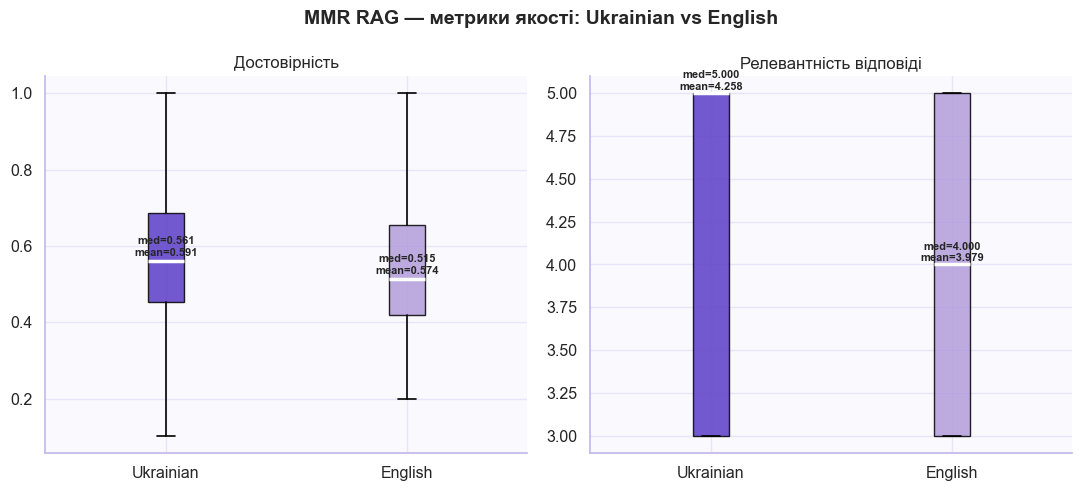

In [60]:
# Метрики якості: faithfulness + answer_relevancy (повне покриття)
LANGS = ["Ukrainian", "English"]
FULL_METRICS = ["faithfulness_report", "answer_relevancy_report"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("MMR RAG — метрики якості: Ukrainian vs English",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, FULL_METRICS):
    data_by_lang = [mmr_raw[mmr_raw["language"] == lang][metric].dropna().values for lang in LANGS]
    colors = [LANG_COLORS[lang] for lang in LANGS]

    bp = ax.boxplot(
        data_by_lang,
        labels=LANGS,
        patch_artist=True,
        medianprops={"color": "white", "linewidth": 2.5},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    for i, vals in enumerate(data_by_lang):
        if len(vals):
            med = np.median(vals)
            mean = np.mean(vals)
            ax.text(i + 1, med + 0.008, f"med={med:.3f}\nmean={mean:.3f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

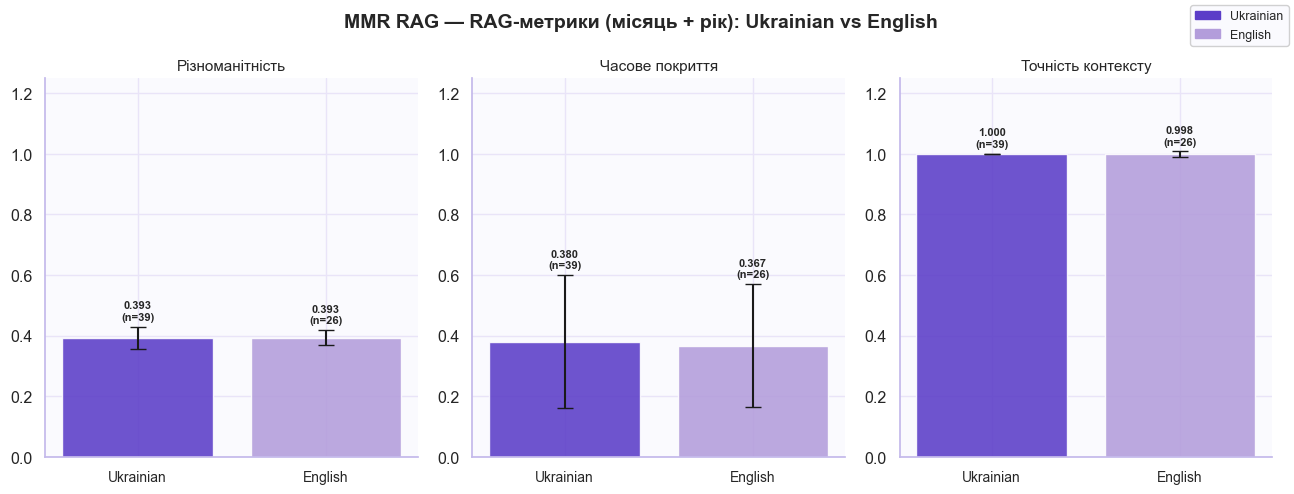

In [61]:
# RAG-метрики для місяць+рік: diversity, temporal_coverage, context_precision
RAG_METRICS = ["diversity", "temporal_coverage", "context_precision"]
mmr_month_year = mmr_raw[mmr_raw["period_type"].isin(["month", "year"])]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("MMR RAG — RAG-метрики (місяць + рік): Ukrainian vs English",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, RAG_METRICS):
    data_by_lang = [mmr_month_year[mmr_month_year["language"] == lang][metric].dropna().values
                    for lang in LANGS]
    means  = [np.mean(v) if len(v) else np.nan for v in data_by_lang]
    stds   = [np.std(v)  if len(v) else 0       for v in data_by_lang]
    colors = [LANG_COLORS[lang] for lang in LANGS]
    ns     = [len(v) for v in data_by_lang]

    bars = ax.bar(
        range(len(LANGS)), means,
        yerr=stds, capsize=6,
        color=colors, edgecolor="white", alpha=0.88
    )
    for i, (bar, val, n) in enumerate(zip(bars, means, ns)):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + stds[i] + 0.015,
                    f"{val:.3f}\n(n={n})",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_title(METRIC_LABELS[metric], fontsize=11)
    ax.set_xticks(range(len(LANGS)))
    ax.set_xticklabels(LANGS, fontsize=10)
    ax.set_ylim(0, 1.25)
    ax.set_xlabel("")

legend_patches = [mpatches.Patch(color=LANG_COLORS[l], label=l) for l in LANGS]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

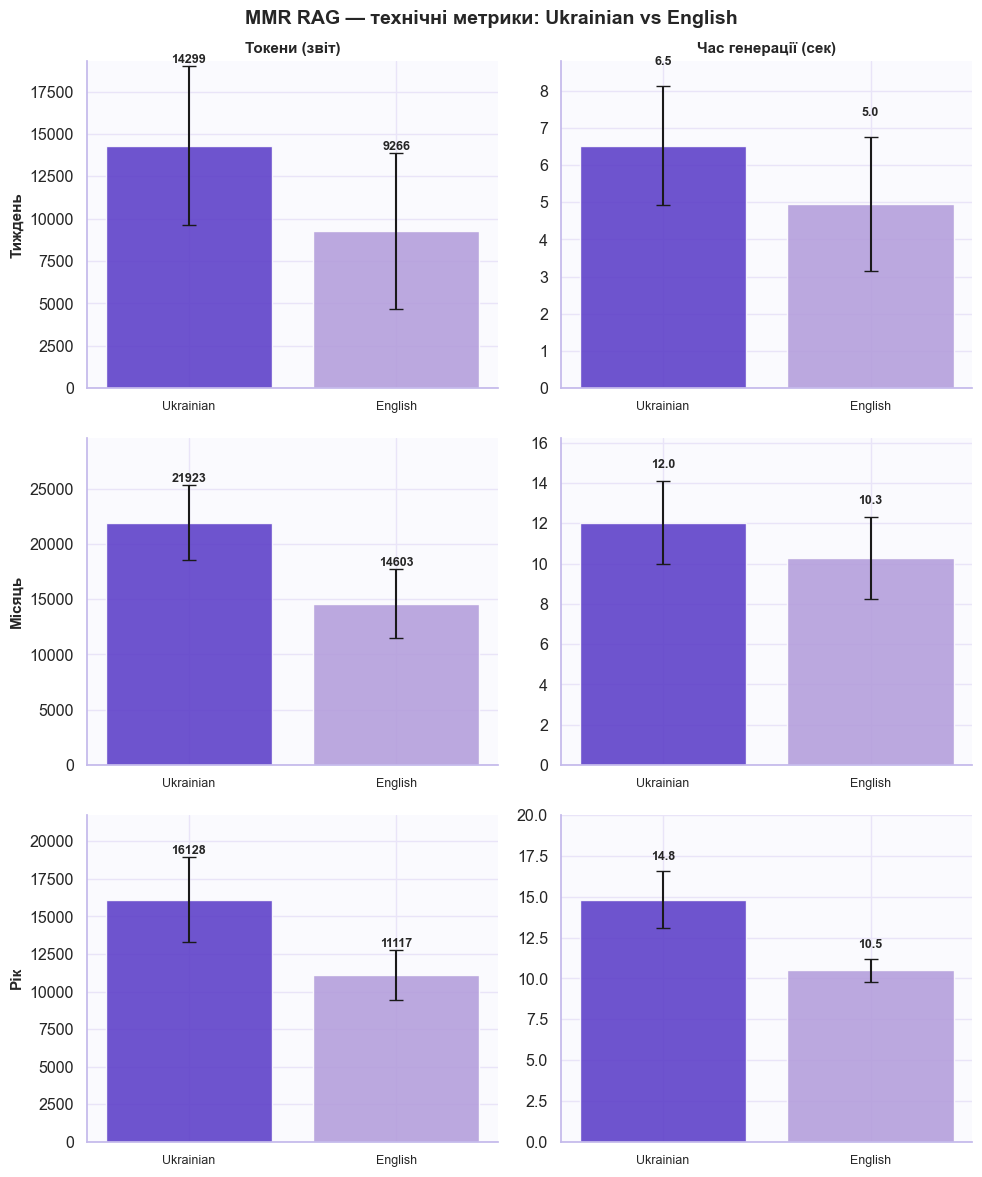

In [62]:
# Технічні метрики: токени і час — розбивка по period_type
fig, axes = plt.subplots(len(PERIOD_ORDER), 2, figsize=(10, 4 * len(PERIOD_ORDER)), squeeze=False)
fig.suptitle("MMR RAG — технічні метрики: Ukrainian vs English", fontsize=14, fontweight="bold")

for r_idx, period in enumerate(PERIOD_ORDER):
    sub = mmr_raw[mmr_raw["period_type"] == period]
    for c_idx, col in enumerate(TECH_COLS):
        ax = axes[r_idx][c_idx]
        data_by_lang = [sub[sub["language"] == lang][col].dropna().values for lang in LANGS]
        means  = [np.mean(v) if len(v) else np.nan for v in data_by_lang]
        stds   = [np.std(v)  if len(v) else 0       for v in data_by_lang]
        colors = [LANG_COLORS[lang] for lang in LANGS]

        bars = ax.bar(
            range(len(LANGS)), means,
            yerr=stds, capsize=5,
            color=colors, edgecolor="white", alpha=0.88
        )
        for i, (bar, val) in enumerate(zip(bars, means)):
            if not np.isnan(val):
                label = f"{val:.0f}" if col == "report_tokens_used" else f"{val:.1f}"
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + stds[i] + 0.5,
                        label, ha="center", va="bottom", fontsize=9, fontweight="bold")

        if r_idx == 0:
            ax.set_title(TECH_LABELS[col], fontsize=11, fontweight="bold")
        if c_idx == 0:
            ax.set_ylabel(PERIOD_LABELS.get(period, period), fontsize=11, fontweight="bold")
        ax.set_xticks(range(len(LANGS)))
        ax.set_xticklabels(LANGS, fontsize=9)
        valid = [v for v in means if not np.isnan(v)]
        if valid:
            ax.set_ylim(0, max(valid) * 1.35)

plt.tight_layout()
plt.show()

In [63]:
# Статистична значущість: Mann-Whitney U для Ukrainian vs English у MMR
print("=== Mann-Whitney U: Ukrainian vs English (MMR RAG) ===\n")

rows = []
test_metrics = {
    "all":        (mmr_raw,        FULL_METRICS),
    "month+year": (mmr_month_year, RAG_METRICS + TECH_COLS),
}
for subset_name, (subset, metrics) in test_metrics.items():
    for metric in metrics:
        a = subset[subset["language"] == "Ukrainian"][metric].dropna().values
        b = subset[subset["language"] == "English"][metric].dropna().values
        if len(a) < 3 or len(b) < 3:
            sig = "⚠️ замало даних"
            p = None
        else:
            _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            sig = "✅ так" if p < 0.05 else "❌ ні"
        rows.append({
            "Дані": subset_name,
            "Метрика": METRIC_LABELS.get(metric, TECH_LABELS.get(metric, metric)),
            "n (UK)": len(a), "n (EN)": len(b),
            "mean (UK)": round(a.mean(), 4) if len(a) else None,
            "mean (EN)": round(b.mean(), 4) if len(b) else None,
            "p-value": round(p, 4) if p is not None else None,
            "Значущо?": sig,
        })

result_df = pd.DataFrame(rows).set_index(["Дані", "Метрика"])
display(result_df)

=== Mann-Whitney U: Ukrainian vs English (MMR RAG) ===



n (UK)  n (EN)   mean (UK)   mean (EN)  \
Дані       Метрика                                                           
all        Достовірність               209     140      0.5909      0.5741   
           Релевантність відповіді     209     140      4.2584      3.9786   
month+year Різноманітність              39      26      0.3929      0.3933   
           Часове покриття              39      26      0.3802      0.3668   
           Точність контексту           39      26      1.0000      0.9981   
           Токени (звіт)                44      31  21264.9091  14040.5161   
           Час генерації (сек)          44      31     12.3489     10.3114   

                                    p-value Значущо?  
Дані       Метрика                                    
all        Достовірність             0.1906     ❌ ні  
           Релевантність відповіді   0.0081    ✅ так  
month+year Різноманітність           1.0000     ❌ ні  
           Часове покриття           0.8508     ❌ ні  
           Точність контексту        0.2327     ❌ ні  
           Токени (звіт)             0.0000    ✅ так  
           Час генерації (сек)       0.0000    ✅ так